In [ ]:
!pip install pymatgen mp-api umap-learn imbalanced-learn scikit-learn matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 4.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 37.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 135.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.4/127.4 kB 16.7 MB/s eta 0:00:00

In [ ]:
import os
import random
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from mp_api.client import MPRester
from pymatgen.analysis.diffraction.xrd import XRDCalculator
from scipy.ndimage import gaussian_filter1d
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras import layers, models, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from sklearn.manifold import TSNE
from matplotlib.patches import Rectangle

In [ ]:
# ============================================================================
# CONFIGURATION & SETUP
# ============================================================================

API_KEY = "sMWxUUzNkgFJyEegqotWyVYFJEtK4N7K"
TARGET_SYSTEMS = ["cubic", "monoclinic", "orthorhombic", "tetragonal"]

TWO_THETA_MIN  = 10
TWO_THETA_MAX  = 110
N_POINTS       = 2048
MAX_PER_CLASS  = 50000

SEED           = 15
EPOCHS_FINAL   = 10
BATCH_SIZE     = 16

XRD_LINE_COLOR  = "#1f77b4"
XRD_LINE_WIDTH  = 0.8
XRD_FRAME_COLOR = "#333333"
XRD_FRAME_WIDTH = 0.9
XRD_DPI         = 120

def set_seed(seed=SEED):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(SEED)
print(f"Seed set to {SEED}")
print(f"Target crystal systems: {TARGET_SYSTEMS}")
print(f"Data Split Ratio - Training:Validation:Testing = 70:10:20")
print(f"Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print(f"Oversampling Method: SMOTE (Standard)")
print(f"Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%")

Seed set to 15
Target crystal systems: ['cubic', 'monoclinic', 'orthorhombic', 'tetragonal']
Data Split Ratio - Training:Validation:Testing = 70:10:20
Epochs: 10 (NO Early Stopping)
Oversampling Method: SMOTE (Standard)
Augmentation Ratio - Orthorhombic:Monoclinic:Tetragonal = 10%:20%:20%


In [ ]:
# ============================================================================
# DATA LOADING FROM MATERIALS PROJECT
# ============================================================================

def load_perovskite_data_from_mp(api_key: str, max_per_class: int = MAX_PER_CLASS):
    """Load perovskite data from Materials Project"""

    data_records = []
    class_counts = {c: 0 for c in TARGET_SYSTEMS}

    with MPRester(api_key) as mpr:
        robo_docs    = mpr.materials.robocrys.search(keywords=["perovskite"])
        perov_mpids  = [str(doc.material_id) for doc in robo_docs][:50000]
        print(f"Found {len(perov_mpids)} perovskite materials")

        summaries = mpr.materials.summary.search(
            material_ids=perov_mpids,
            fields=["material_id", "structure", "symmetry", "formula_pretty",
                    "density", "volume", "nsites"],
        )

        for doc in summaries:
            sym = getattr(doc, "symmetry", None)
            if sym is None or sym.crystal_system is None:
                continue

            cs_raw = sym.crystal_system
            if hasattr(cs_raw, "value"):
                cs = str(cs_raw.value).lower()
            else:
                cs_str = str(cs_raw)
                if "." in cs_str:
                    cs_str = cs_str.split(".")[-1]
                cs = cs_str.lower()

            if cs not in TARGET_SYSTEMS:
                continue
            if class_counts[cs] >= max_per_class:
                continue

            structure = doc.structure
            if structure is None:
                continue

            record = {
                'material_id'  : str(doc.material_id),
                'formula'      : str(doc.formula_pretty) if hasattr(doc, 'formula_pretty') else None,
                'crystal_system': cs,
                'density'      : float(doc.density)  if hasattr(doc, 'density')  else None,
                'volume'       : float(doc.volume)   if hasattr(doc, 'volume')   else None,
                'nsites'       : int(doc.nsites)     if hasattr(doc, 'nsites')   else None,
                'structure'    : structure
            }

            data_records.append(record)
            class_counts[cs] += 1

            if all(class_counts[c] >= max_per_class for c in TARGET_SYSTEMS):
                break

    print(f"\nTotal materials collected: {len(data_records)}")
    print(f"Class distribution: {class_counts}")
    return pd.DataFrame(data_records)

print("\n" + "="*70)
print("LOADING DATA FROM MATERIALS PROJECT")
print("="*70)
df_materials = load_perovskite_data_from_mp(API_KEY)
print(f"\nDataset shape: {df_materials.shape}")


LOADING DATA FROM MATERIALS PROJECT


Retrieving RobocrystallogapherDoc documents:   0%|          | 0/8509 [00:00<?, ?it/s]

Found 8509 perovskite materials


Retrieving SummaryDoc documents:   0%|          | 0/7886 [00:00<?, ?it/s]


Total materials collected: 7015
Class distribution: {'cubic': 4877, 'monoclinic': 869, 'orthorhombic': 1003, 'tetragonal': 266}

Dataset shape: (7015, 7)


In [ ]:
# ============================================================================
# DATA EXPLORATION
# ============================================================================

print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(df_materials.dtypes)

print("\n" + "="*70)
print("COLUMNS/FEATURES")
print("="*70)
print(f"Columns: {list(df_materials.columns)}")

print("\n" + "="*70)
print("TOP 4 SAMPLES (Preview)")
print("="*70)
display_df = df_materials.drop(columns=['structure']).head(4)
print(display_df.to_string())


DATA TYPES
material_id        object
formula            object
crystal_system     object
density           float64
volume            float64
nsites              int64
structure          object
dtype: object

COLUMNS/FEATURES
Columns: ['material_id', 'formula', 'crystal_system', 'density', 'volume', 'nsites', 'structure']

TOP 4 SAMPLES (Preview)
  material_id formula crystal_system   density     volume  nsites
0  mp-1183499  BePbO3          cubic  9.003622  48.728353       5
1  mp-1183476  BeReO3          cubic  9.797645  41.221332       5
2  mp-1183449   BeVO3          cubic  4.446282  40.316453       5
3  mp-1183436  BeInO3          cubic  6.342490  44.986706       5


In [ ]:
# ============================================================================
# MISSING VALUES ANALYSIS
# ============================================================================

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

missing_data    = df_materials.isnull().sum()
missing_percent = (df_materials.isnull().sum() / len(df_materials)) * 100

missing_df = pd.DataFrame({
    'Column'             : missing_data.index,
    'Missing Count'      : missing_data.values,
    'Missing Percentage' : missing_percent.values
})
print(missing_df.to_string(index=False))

if missing_percent.sum() > 0:
    plt.figure(figsize=(10, 6))
    missing_percent[missing_percent > 0].plot(kind='bar', color='coral', edgecolor='black')
    plt.title('Missing Values Percentage by Column', fontweight='bold', fontsize=14)
    plt.xlabel('Column', fontsize=12)
    plt.ylabel('Missing Percentage (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print(f"\n⚠ Total missing values: {missing_data.sum()}")
else:
    print("\n" + "="*70)
    print("✓ NO MISSING VALUES FOUND!")
    print("="*70)
    print("All columns are complete. Data quality is excellent!")


MISSING VALUES ANALYSIS
        Column  Missing Count  Missing Percentage
   material_id              0                 0.0
       formula              0                 0.0
crystal_system              0                 0.0
       density              0                 0.0
        volume              0                 0.0
        nsites              0                 0.0
     structure              0                 0.0

✓ NO MISSING VALUES FOUND!
All columns are complete. Data quality is excellent!



CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)

Count by Crystal System:
crystal_system
cubic           4877
orthorhombic    1003
monoclinic       869
tetragonal       266
Name: count, dtype: int64

Percentage by Crystal System:
  Cubic          :  69.52%
  Orthorhombic   :  14.30%
  Monoclinic     :  12.39%
  Tetragonal     :   3.79%


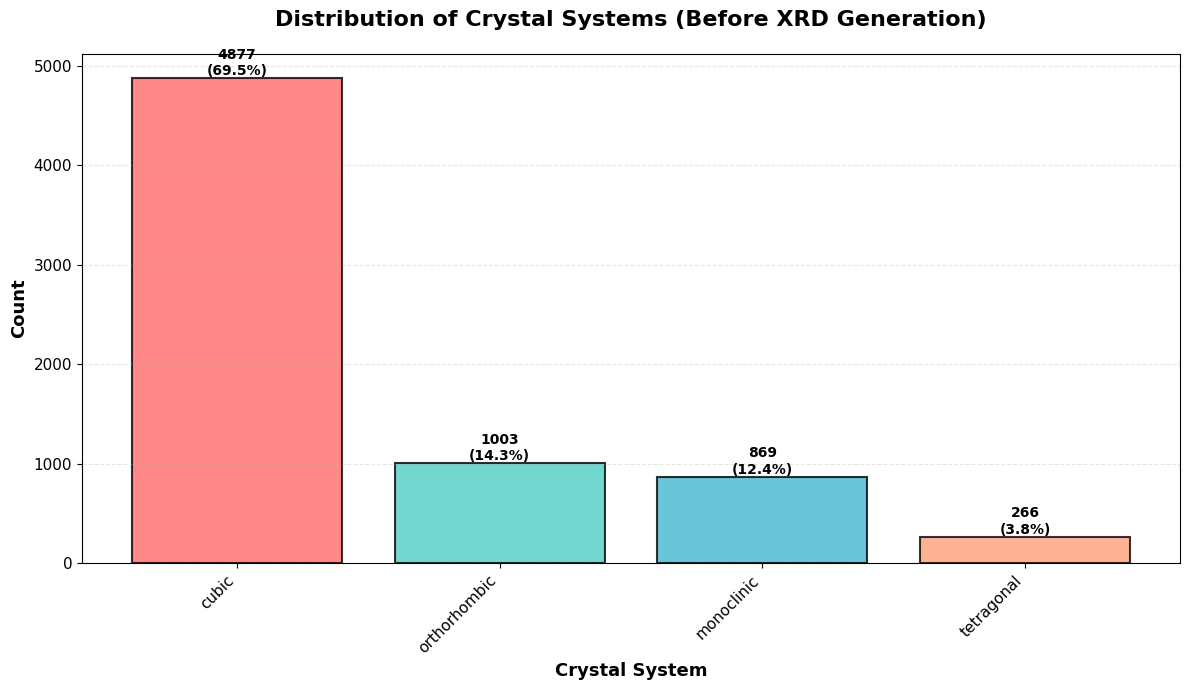

In [ ]:
# ============================================================================
# CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)
# ============================================================================

print("\n" + "="*70)
print("CRYSTAL SYSTEM DISTRIBUTION (BEFORE XRD GENERATION)")
print("="*70)

class_distribution     = df_materials['crystal_system'].value_counts()
class_distribution_pct = (class_distribution / len(df_materials) * 100).round(2)

print("\nCount by Crystal System:")
print(class_distribution)
print("\nPercentage by Crystal System:")
for system, pct in class_distribution_pct.items():
    print(f"  {system.capitalize():<15}: {pct:>6.2f}%")

plt.figure(figsize=(12, 7))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars   = plt.bar(class_distribution.index, class_distribution.values,
                  color=colors[:len(class_distribution)],
                  edgecolor='black', linewidth=1.5, alpha=0.8)

plt.title('Distribution of Crystal Systems (Before XRD Generation)',
          fontweight='bold', fontsize=16, pad=20)
plt.xlabel('Crystal System', fontsize=13, fontweight='bold')
plt.ylabel('Count', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.grid(axis='y', alpha=0.3, linestyle='--')

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}\n({height/len(df_materials)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# XRD PATTERN GENERATION  ── Gaussian-peak method
# ============================================================================

def build_gaussian_pattern(peak_2theta, peak_intensity,
                            two_theta_grid,
                            theta_min=TWO_THETA_MIN,
                            theta_max=TWO_THETA_MAX):
    """
    Place narrow Gaussians at each (2θ, I) peak → realistic XRD profile.
    Mirrors create_smooth_xrd() from plot_XRD.ipynb.
    """
    y     = np.zeros(len(two_theta_grid), dtype=np.float32)
    i_max = np.max(peak_intensity) if len(peak_intensity) > 0 else 1.0
    if i_max == 0:
        i_max = 1.0

    for t, i in zip(peak_2theta, peak_intensity):
        if not (theta_min <= t <= theta_max):
            continue
        fwhm  = 0.12 + 0.0008 * t
        sigma = fwhm / (2.0 * np.sqrt(2.0 * np.log(2)))
        y    += (i / i_max) * np.exp(-0.5 * ((two_theta_grid - t) / sigma) ** 2)

    np.random.seed(SEED)
    base = np.random.normal(0, 0.006, y.size).astype(np.float32)
    base = gaussian_filter1d(base, sigma=75).astype(np.float32)
    y   += np.abs(base)

    y = gaussian_filter1d(y, sigma=1.1).astype(np.float32)
    y = np.clip(y, 0, None)

    peak = np.max(y)
    if peak > 0:
        y /= peak

    return y


def generate_xrd_patterns(df_mat,
                           two_theta_min=TWO_THETA_MIN,
                           two_theta_max=TWO_THETA_MAX,
                           n_points=N_POINTS):
    """Generate XRD patterns (Gaussian-peak method) from pymatgen structures."""

    two_theta_grid                                  = np.linspace(two_theta_min, two_theta_max, n_points)
    X_patterns, y_systems                           = [], []
    material_ids, formulas, valid_indices           = [], [], []
    failed_count                                    = 0

    xrd_calc = XRDCalculator(wavelength="CuKa")

    print("="*70)
    print("GENERATING XRD PATTERNS  (Gaussian-peak method)")
    print("="*70)
    print(f"2θ range  : {two_theta_min}° – {two_theta_max}°")
    print(f"Points    : {n_points}")
    print(f"Wavelength: Cu Kα\n")

    total = len(df_mat)

    for idx, row in df_mat.iterrows():
        try:
            pattern = xrd_calc.get_pattern(
                row['structure'],
                two_theta_range=(two_theta_min, two_theta_max),
            )

            intensities = build_gaussian_pattern(
                pattern.x, pattern.y, two_theta_grid,
                theta_min=two_theta_min, theta_max=two_theta_max
            )

            X_patterns.append(intensities)
            y_systems.append(row['crystal_system'])
            material_ids.append(row['material_id'])
            formulas.append(row['formula'])
            valid_indices.append(idx)

        except Exception as e:
            failed_count += 1
            if failed_count <= 3:
                print(f"✗ Error {row['material_id']}: {str(e)[:60]}...")
            continue

        if len(X_patterns) % 500 == 0 and len(X_patterns) > 0:
            pct = len(X_patterns) / total * 100
            print(f"  ✓ {len(X_patterns):>5}/{total} ({pct:.1f}%)")

    X_patterns   = np.array(X_patterns,  dtype=np.float32)
    y_systems    = np.array(y_systems)
    material_ids = np.array(material_ids)
    formulas     = np.array(formulas)

    ok  = len(X_patterns)
    tot = ok + failed_count
    print(f"\n{'='*70}")
    print(f"XRD GENERATION SUMMARY")
    print(f"{'='*70}")
    print(f"  ✓ Generated : {ok}")
    print(f"  ✗ Failed    : {failed_count}")
    print(f"  Success     : {ok/tot*100:.2f}%")
    print(f"  Shape       : {X_patterns.shape}")
    print(f"  Distribution: {Counter(y_systems)}")

    return two_theta_grid, X_patterns, y_systems, material_ids, formulas, valid_indices


two_theta_grid, X_raw, y_str, material_ids, formulas, valid_idx = \
    generate_xrd_patterns(df_materials)

df_materials = df_materials.iloc[valid_idx].reset_index(drop=True)
print(f"\n✓ Final dataset size: {len(X_raw)} samples")

GENERATING XRD PATTERNS  (Gaussian-peak method)
2θ range  : 10° – 110°
Points    : 2048
Wavelength: Cu Kα

  ✓   500/7015 (7.1%)
  ✓  1000/7015 (14.3%)
  ✓  1500/7015 (21.4%)
  ✓  2000/7015 (28.5%)
  ✓  2500/7015 (35.6%)
  ✓  3000/7015 (42.8%)
  ✓  3500/7015 (49.9%)
  ✓  4000/7015 (57.0%)
  ✓  4500/7015 (64.1%)
  ✓  5000/7015 (71.3%)
  ✓  5500/7015 (78.4%)
  ✓  6000/7015 (85.5%)
  ✓  6500/7015 (92.7%)
  ✓  7000/7015 (99.8%)

XRD GENERATION SUMMARY
  ✓ Generated : 7015
  ✗ Failed    : 0
  Success     : 100.00%
  Shape       : (7015, 2048)
  Distribution: Counter({np.str_('cubic'): 4877, np.str_('orthorhombic'): 1003, np.str_('monoclinic'): 869, np.str_('tetragonal'): 266})

✓ Final dataset size: 7015 samples



PREPROCESSING: MAX SCALING NORMALIZATION

[BEFORE Max Scaling]
  Min  value (global) : 0.000000
  Max  value (global) : 1.000000
  Mean value (global) : 0.010757
  Std  value (global) : 0.054920

[AFTER Max Scaling]
  Min  value (global) : 0.000000
  Max  value (global) : 1.000000
  Mean value (global) : 0.010757
  Std  value (global) : 0.054920

  Samples with max = 1.0 : 7015 / 7015  (100.00%)
  ✓ ALL samples correctly normalized — max intensity = 1.0


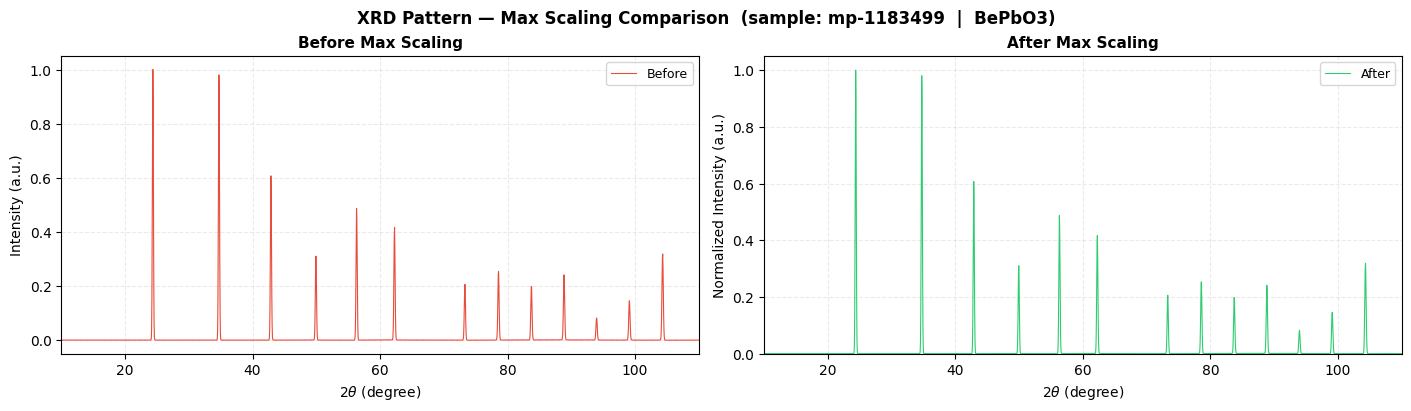

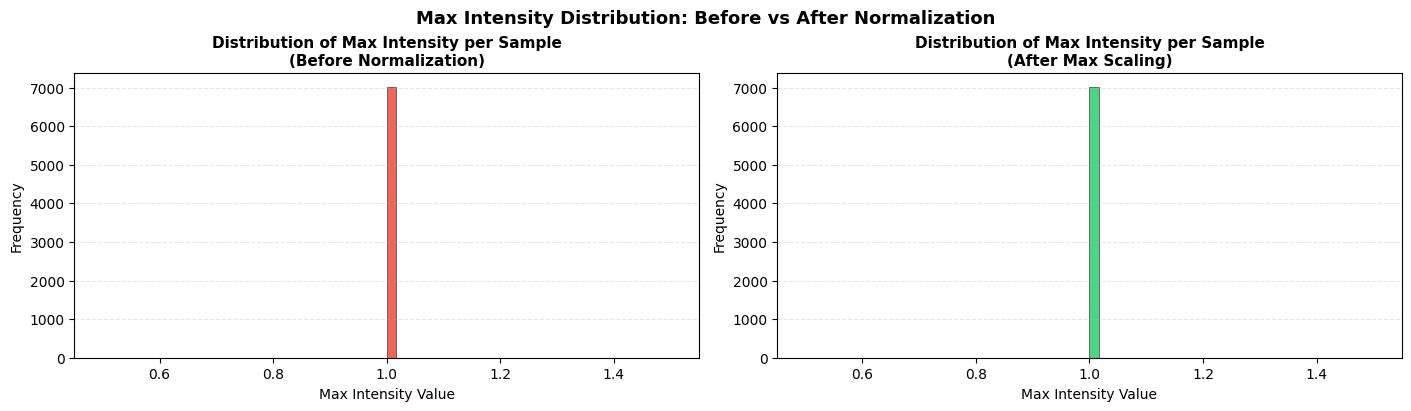


✓ Max Scaling normalization complete!
  X_normalized shape : (7015, 2048)
  dtype              : float32


In [ ]:
# ============================================================================
# PREPROCESSING: MAX SCALING NORMALIZATION
# ============================================================================
#
#   Tujuan : Memastikan setiap pola XRD memiliki intensitas puncak = 1.0
#            sehingga skala antar-sampel seragam sebelum masuk model.
#
#   Rumus  : x_norm[i] = x[i] / max(x[i])
#
#   Catatan: Normalisasi dilakukan per-sampel (sample-wise), bukan per-fitur,
#            karena XRD pattern adalah sinyal 1-D dengan puncak relatif.
# ============================================================================

print("\n" + "="*70)
print("PREPROCESSING: MAX SCALING NORMALIZATION")
print("="*70)

# ── Statistik SEBELUM normalisasi ─────────────────────────────────────────
print("\n[BEFORE Max Scaling]")
print(f"  Min  value (global) : {X_raw.min():.6f}")
print(f"  Max  value (global) : {X_raw.max():.6f}")
print(f"  Mean value (global) : {X_raw.mean():.6f}")
print(f"  Std  value (global) : {X_raw.std():.6f}")

# ── Hitung max per sampel, hindari pembagian nol ───────────────────────────
sample_maxima = X_raw.max(axis=1, keepdims=True)          # shape (N, 1)
sample_maxima = np.where(sample_maxima == 0, 1.0, sample_maxima)

# ── Terapkan Max Scaling ───────────────────────────────────────────────────
X_normalized = (X_raw / sample_maxima).astype(np.float32)

# ── Verifikasi hasil ───────────────────────────────────────────────────────
normalized_maxima = X_normalized.max(axis=1)
n_perfect = np.sum(np.isclose(normalized_maxima, 1.0, atol=1e-5))

print("\n[AFTER Max Scaling]")
print(f"  Min  value (global) : {X_normalized.min():.6f}")
print(f"  Max  value (global) : {X_normalized.max():.6f}")
print(f"  Mean value (global) : {X_normalized.mean():.6f}")
print(f"  Std  value (global) : {X_normalized.std():.6f}")
print(f"\n  Samples with max = 1.0 : {n_perfect} / {len(X_normalized)}"
      f"  ({n_perfect/len(X_normalized)*100:.2f}%)")

if n_perfect == len(X_normalized):
    print("  ✓ ALL samples correctly normalized — max intensity = 1.0")
else:
    n_fail = len(X_normalized) - n_perfect
    print(f"  ⚠ {n_fail} samples NOT perfectly normalized (check zero-intensity patterns)")

# ── Visualisasi perbandingan satu sampel ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

sample_idx = 0
axes[0].plot(two_theta_grid, X_raw[sample_idx],
             color="#e74c3c", linewidth=0.8, label="Before")
axes[0].set_title("Before Max Scaling", fontweight="bold", fontsize=11)
axes[0].set_xlabel(r"2$\theta$ (degree)", fontsize=10)
axes[0].set_ylabel("Intensity (a.u.)", fontsize=10)
axes[0].set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)
axes[0].grid(alpha=0.25, linestyle="--")
axes[0].legend(fontsize=9)

axes[1].plot(two_theta_grid, X_normalized[sample_idx],
             color="#2ecc71", linewidth=0.8, label="After")
axes[1].set_title("After Max Scaling", fontweight="bold", fontsize=11)
axes[1].set_xlabel(r"2$\theta$ (degree)", fontsize=10)
axes[1].set_ylabel("Normalized Intensity (a.u.)", fontsize=10)
axes[1].set_xlim(TWO_THETA_MIN, TWO_THETA_MAX)
axes[1].set_ylim(0, 1.05)
axes[1].grid(alpha=0.25, linestyle="--")
axes[1].legend(fontsize=9)

fig.suptitle(
    f"XRD Pattern — Max Scaling Comparison  (sample: {material_ids[sample_idx]}  |  {formulas[sample_idx]})",
    fontweight="bold", fontsize=12
)
plt.show()

# ── Distribusi nilai maksimum per sampel (histogram) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

axes[0].hist(X_raw.max(axis=1), bins=60, color="#e74c3c", edgecolor="black",
             linewidth=0.4, alpha=0.85)
axes[0].set_title("Distribution of Max Intensity per Sample\n(Before Normalization)",
                   fontweight="bold", fontsize=11)
axes[0].set_xlabel("Max Intensity Value", fontsize=10)
axes[0].set_ylabel("Frequency", fontsize=10)
axes[0].grid(axis='y', alpha=0.3, linestyle="--")

axes[1].hist(X_normalized.max(axis=1), bins=60, color="#2ecc71", edgecolor="black",
             linewidth=0.4, alpha=0.85)
axes[1].set_title("Distribution of Max Intensity per Sample\n(After Max Scaling)",
                   fontweight="bold", fontsize=11)
axes[1].set_xlabel("Max Intensity Value", fontsize=10)
axes[1].set_ylabel("Frequency", fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle="--")

fig.suptitle("Max Intensity Distribution: Before vs After Normalization",
             fontweight="bold", fontsize=13)
plt.show()

print("\n✓ Max Scaling normalization complete!")
print(f"  X_normalized shape : {X_normalized.shape}")
print(f"  dtype              : {X_normalized.dtype}")


XRD PATTERN VISUALIZATION  —  Normalized (Max Scaling)
           Cubic:  4877 samples
      Monoclinic:   869 samples
    Orthorhombic:  1003 samples
      Tetragonal:   266 samples


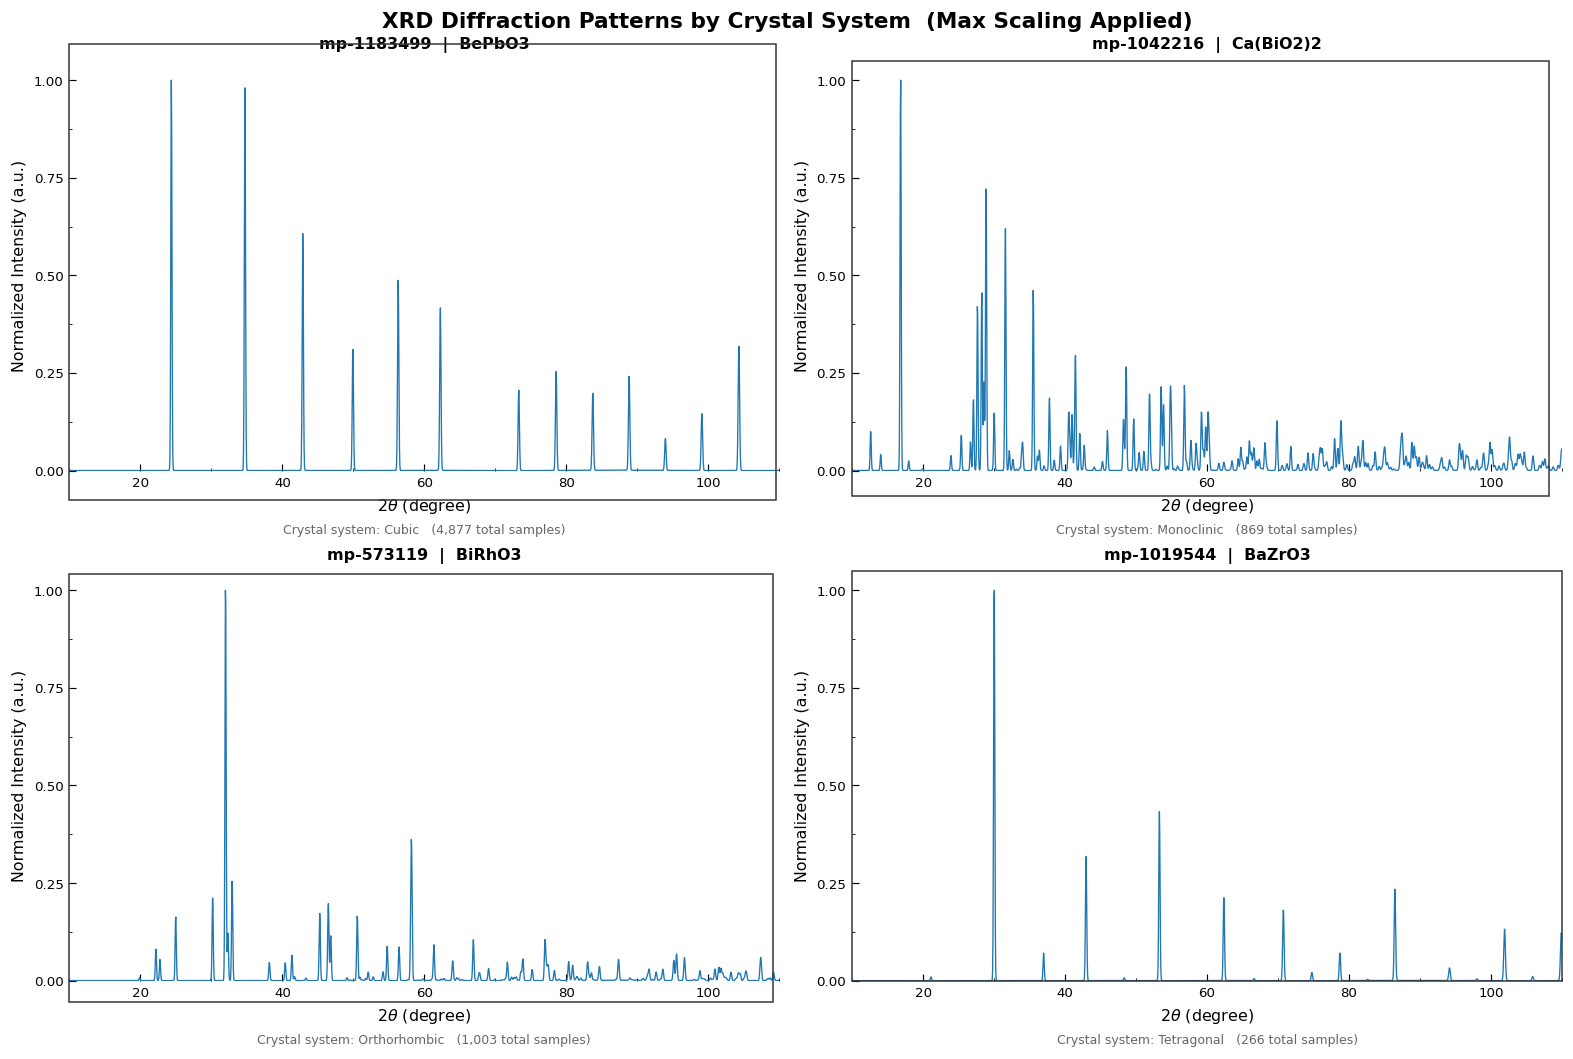


✓ XRD visualisation complete!


In [ ]:
# ============================================================================
# XRD PATTERN VISUALIZATION  ── Blue line, garis tidak keluar kotak
# ============================================================================
import matplotlib.ticker as ticker

def _draw_outer_frame(fig, ax,
                      color=XRD_FRAME_COLOR,
                      lw=XRD_FRAME_WIDTH):
    fig.canvas.draw()
    x0, y0, w, h = ax.get_position().bounds
    rect = Rectangle(
        (x0, y0), w, h,
        transform=fig.transFigure,
        fill=False,
        edgecolor=color,
        linewidth=lw,
        zorder=10,
    )
    fig.add_artist(rect)


def _style_xrd_ax(ax, fig, title_str,
                  x_min=TWO_THETA_MIN, x_max=TWO_THETA_MAX):
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(0, 1.05)

    ax.set_xlabel(r"2$\theta$ (degree)", fontsize=9.5, labelpad=4)
    ax.set_ylabel("Normalized Intensity (a.u.)", fontsize=9.5, labelpad=4)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(20))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(10))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.25))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.125))
    ax.tick_params(axis="both", which="major",
                   direction="in", length=4, width=0.7, labelsize=8)
    ax.tick_params(axis="both", which="minor",
                   direction="in", length=2, width=0.5)

    ax.set_clip_on(True)
    for line in ax.get_lines():
        line.set_clip_on(True)

    for spine in ax.spines.values():
        spine.set_visible(False)

    _draw_outer_frame(fig, ax)
    ax.set_title(title_str, fontsize=9.5, fontweight="bold", pad=7, loc="center")


print("\n" + "="*70)
print("XRD PATTERN VISUALIZATION  —  Normalized (Max Scaling)")
print("="*70)

np.random.seed(SEED)

fig, axes = plt.subplots(2, 2,
                          figsize=(13, 8.5),
                          dpi=XRD_DPI,
                          constrained_layout=True)
axes_flat = axes.ravel()

for i, system in enumerate(TARGET_SYSTEMS):
    ax      = axes_flat[i]
    idx     = np.where(y_str == system)[0]
    print(f"  {system.capitalize():>14s}: {len(idx):>5d} samples")

    if len(idx) == 0:
        ax.set_visible(False)
        continue

    sample_i = idx[0]
    formula  = formulas[sample_i]
    mid      = material_ids[sample_i]

    # ── Plot menggunakan data yang sudah dinormalisasi ──────────────────────
    ax.plot(two_theta_grid, X_normalized[sample_i],
            color=XRD_LINE_COLOR,
            linewidth=XRD_LINE_WIDTH,
            clip_on=True)

    _style_xrd_ax(ax, fig, f"{mid}  |  {formula}")

    ax.annotate(
        f"Crystal system: {system.capitalize()}   ({len(idx):,} total samples)",
        xy=(0.5, -0.13), xycoords="axes fraction",
        ha="center", va="top",
        fontsize=7.5, color="#666666",
        annotation_clip=False,
    )

fig.suptitle("XRD Diffraction Patterns by Crystal System  (Max Scaling Applied)",
             fontsize=13, fontweight="bold", y=1.02)
plt.show()
print("\n✓ XRD visualisation complete!")

In [ ]:
# ============================================================================
# DATA PREPARATION: ENCODING & SPLITTING (70:10:20)
# ============================================================================
#
#   PENTING: Seluruh pipeline splitting & SMOTE menggunakan X_normalized
#            (bukan X_raw) agar normalisasi konsisten di semua subset.
# ============================================================================

print("\n" + "="*70)
print("DATA PREPARATION: ENCODING & SPLITTING")
print("="*70)

le          = LabelEncoder()
y_encoded   = le.fit_transform(y_str)
class_names = list(le.classes_)

print("\nClass Encoding Mapping:")
for i, name in enumerate(class_names):
    count = np.sum(y_encoded == i)
    print(f"  {i} → {name.capitalize():<15} ({count} samples)")

# ── Split menggunakan X_normalized ────────────────────────────────────────
# 80% temp → 20% test
X_temp, X_test_raw, y_temp, y_test = train_test_split(
    X_normalized, y_encoded,          # ← X_normalized
    test_size=0.20,
    random_state=SEED,
    stratify=y_encoded
)

# 70% train → 10% validation (10/80 = 0.125)
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,
    random_state=SEED,
    stratify=y_temp
)

print("\n" + "-"*70)
print("DATA SPLIT (70% Train / 10% Validation / 20% Test)")
print("-"*70)
print(f"Training set size:     {len(X_train_raw):>6} samples ({len(X_train_raw)/len(X_normalized)*100:.1f}%)")
print(f"Validation set size:   {len(X_val_raw):>6} samples ({len(X_val_raw)/len(X_normalized)*100:.1f}%)")
print(f"Test set size:         {len(X_test_raw):>6} samples ({len(X_test_raw)/len(X_normalized)*100:.1f}%)")
print(f"Total:                 {len(X_normalized):>6} samples")

print("\nTraining Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_train == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_train)*100:>5.1f}%)")

print("\nValidation Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_val == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_val)*100:>5.1f}%)")

print("\nTest Set Distribution:")
for i, name in enumerate(class_names):
    count = np.sum(y_test == i)
    print(f"  {name.capitalize():<15}: {count:>5} samples ({count/len(y_test)*100:>5.1f}%)")


DATA PREPARATION: ENCODING & SPLITTING

Class Encoding Mapping:
  0 → Cubic           (4877 samples)
  1 → Monoclinic      (869 samples)
  2 → Orthorhombic    (1003 samples)
  3 → Tetragonal      (266 samples)

----------------------------------------------------------------------
DATA SPLIT (70% Train / 10% Validation / 20% Test)
----------------------------------------------------------------------
Training set size:       4910 samples (70.0%)
Validation set size:      702 samples (10.0%)
Test set size:           1403 samples (20.0%)
Total:                   7015 samples

Training Set Distribution:
  Cubic          :  3414 samples ( 69.5%)
  Monoclinic     :   608 samples ( 12.4%)
  Orthorhombic   :   702 samples ( 14.3%)
  Tetragonal     :   186 samples (  3.8%)

Validation Set Distribution:
  Cubic          :   488 samples ( 69.5%)
  Monoclinic     :    87 samples ( 12.4%)
  Orthorhombic   :   100 samples ( 14.2%)
  Tetragonal     :    27 samples (  3.8%)

Test Set Distribution:
 

In [ ]:
# ============================================================================
# SMOTE: CUSTOM AUGMENTATION
#   Orthorhombic: +10%  |  Monoclinic: +20%  |  Tetragonal: +20%
# ============================================================================

print("\n" + "="*70)
print("SMOTE: CUSTOM AUGMENTATION")
print("="*70)

counts_before = Counter(y_train)
print("\nClass counts BEFORE SMOTE:")
for i, name in enumerate(class_names):
    print(f"  {name.capitalize():<15}: {counts_before[i]}")

# Hitung target per kelas
smote_targets = {}
for i, name in enumerate(class_names):
    n = counts_before[i]
    if name == "orthorhombic":
        smote_targets[i] = int(n * 1.10)
    elif name in "monoclinic":
        smote_targets[i] = int(n * 1.20)
    elif name == "tetragonal":
        smote_targets[i] = int(n * 4.20)
    else:                          # cubic → tidak di-oversample
        smote_targets[i] = n

print("\nSMOTE sampling strategy (target per class):")
for i, name in enumerate(class_names):
    print(f"  {name.capitalize():<15}: {counts_before[i]} → {smote_targets[i]}")

smote = SMOTE(sampling_strategy=smote_targets, random_state=SEED)
X_train_smote, y_train_smote = smote.fit_resample(X_train_raw, y_train)
X_train_smote = X_train_smote.astype(np.float32)

counts_after = Counter(y_train_smote)
print("\nClass counts AFTER SMOTE:")
for i, name in enumerate(class_names):
    print(f"  {name.capitalize():<15}: {counts_after[i]}")

print(f"\n✓ SMOTE complete!  Shape: {X_train_smote.shape}")


SMOTE: CUSTOM AUGMENTATION

Class counts BEFORE SMOTE:
  Cubic          : 3414
  Monoclinic     : 608
  Orthorhombic   : 702
  Tetragonal     : 186

SMOTE sampling strategy (target per class):
  Cubic          : 3414 → 3414
  Monoclinic     : 608 → 729
  Orthorhombic   : 702 → 772
  Tetragonal     : 186 → 781

Class counts AFTER SMOTE:
  Cubic          : 3414
  Monoclinic     : 729
  Orthorhombic   : 772
  Tetragonal     : 781

✓ SMOTE complete!  Shape: (5696, 2048)


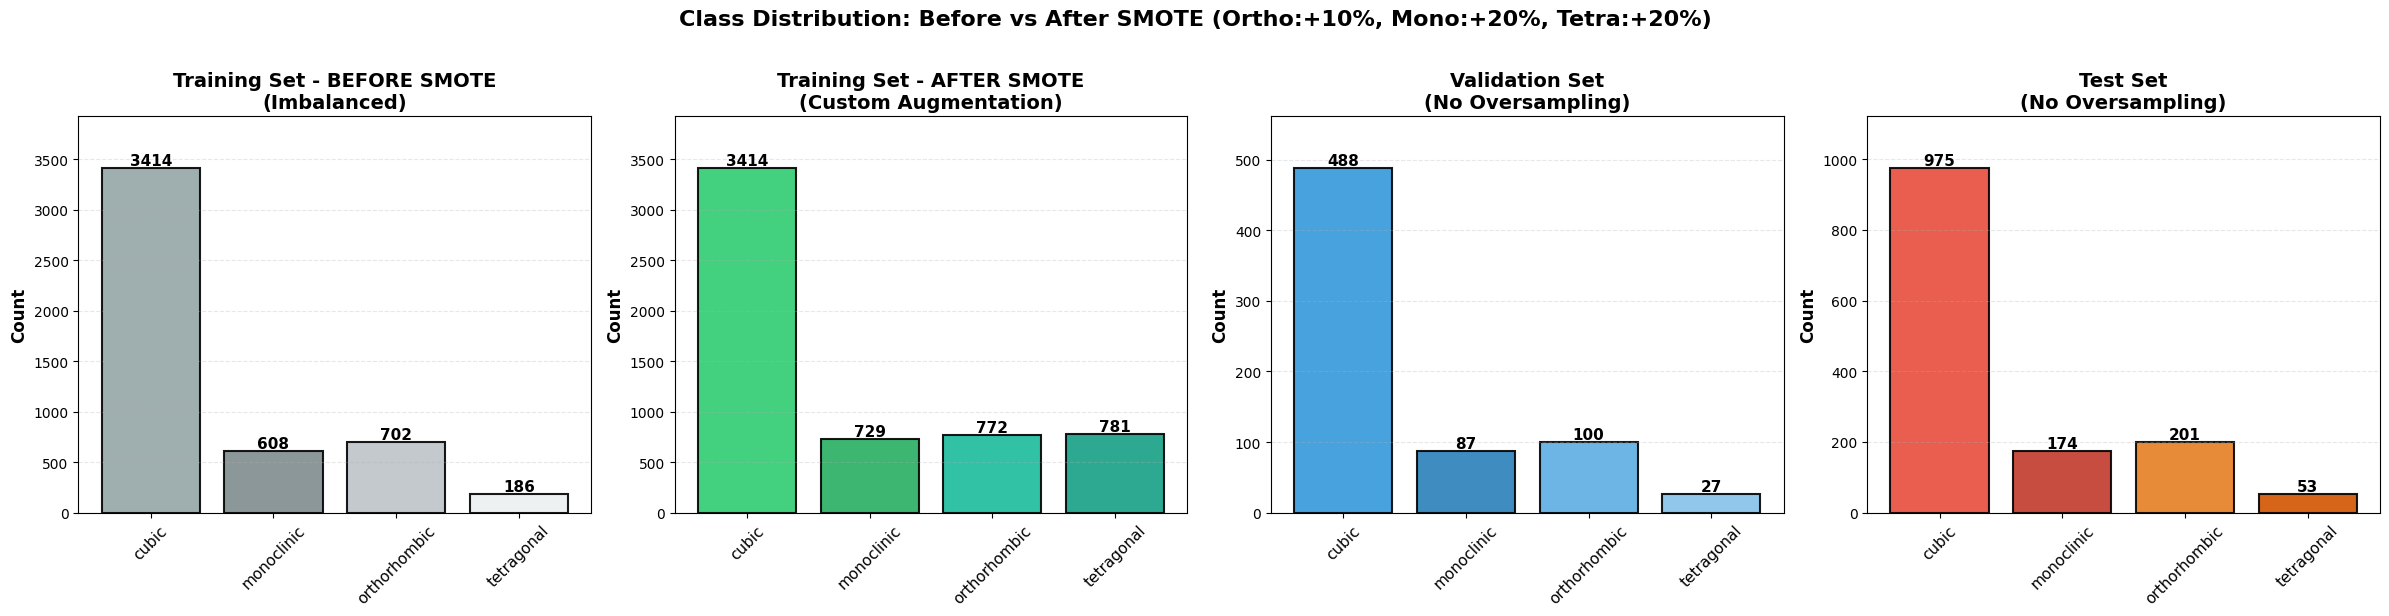

In [ ]:
# ============================================================================
# VISUALIZE CLASS DISTRIBUTION COMPARISON
# ============================================================================

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

colors_before = ['#95a5a6', '#7f8c8d', '#bdc3c7', '#ecf0f1']
colors_after  = ['#2ecc71', '#27ae60', '#1abc9c', '#16a085']
colors_val    = ['#3498db', '#2980b9', '#5dade2', '#85c1e9']
colors_test   = ['#e74c3c', '#c0392b', '#e67e22', '#d35400']

datasets = [
    (y_train,       colors_before, 'Training Set - BEFORE SMOTE\n(Imbalanced)'),
    (y_train_smote, colors_after,  'Training Set - AFTER SMOTE\n(Custom Augmentation)'),
    (y_val,         colors_val,    'Validation Set\n(No Oversampling)'),
    (y_test,        colors_test,   'Test Set\n(No Oversampling)'),
]

for ax, (y_data, colors, title) in zip(axes, datasets):
    unique, counts = np.unique(y_data, return_counts=True)
    labels         = [class_names[i] for i in unique]
    bars           = ax.bar(labels, counts, color=colors,
                             edgecolor='black', linewidth=1.5, alpha=0.9)
    ax.set_title(title, fontweight='bold', fontsize=14)
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, max(counts) * 1.15)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                f'{int(count)}', ha='center', va='bottom',
                fontweight='bold', fontsize=11)

plt.suptitle('Class Distribution: Before vs After SMOTE (Ortho:+10%, Mono:+20%, Tetra:+20%)',
             fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# PREPARE DATA FOR TRAINING
# ============================================================================

# Reshape untuk CNN (tambah channel dimension)
X_train_no_smote  = X_train_raw[..., np.newaxis]
X_train_with_smote = X_train_smote[..., np.newaxis]
X_val              = X_val_raw[..., np.newaxis]
X_test             = X_test_raw[..., np.newaxis]

print("\n" + "="*70)
print("DATA SHAPES FOR TRAINING")
print("="*70)
print(f"X_train (no SMOTE)   : {X_train_no_smote.shape}")
print(f"X_train (with SMOTE) : {X_train_with_smote.shape}")
print(f"X_val                : {X_val.shape}")
print(f"X_test               : {X_test.shape}")
print(f"\nInput range  — min: {X_train_with_smote.min():.4f}  max: {X_train_with_smote.max():.4f}")
print("\n✓ All data ready for training! (Max Scaling already applied)")


DATA SHAPES FOR TRAINING
X_train (no SMOTE)   : (4910, 2048, 1)
X_train (with SMOTE) : (5696, 2048, 1)
X_val                : (702, 2048, 1)
X_test               : (1403, 2048, 1)

Input range  — min: 0.0000  max: 1.0000

✓ All data ready for training! (Max Scaling already applied)


In [ ]:
# ============================================================================
# MODEL ARCHITECTURE DEFINITIONS
# ============================================================================

def build_cnn_fixed(input_shape, num_classes: int):
    """CNN with fixed architecture — 3 Conv1D + 2 FC layers"""
    inputs = layers.Input(shape=input_shape)

    x = layers.Conv1D(filters=80, kernel_size=80, strides=5,
                      activation="relu", padding="same", name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    x = layers.Conv1D(filters=80, kernel_size=40, strides=5,
                      activation="relu", padding="same", name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    x = layers.Conv1D(filters=80, kernel_size=20, strides=5,
                      activation="relu", padding="same", name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)
    x = layers.Dense(64,  activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    model   = models.Model(inputs, outputs, name="CNN_Fixed")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model


def build_cnn_woa(params, input_shape, num_classes):
    num_filters = int(params[0])
    fc1_units   = int(params[1])
    fc2_units   = int(params[2])

    inputs = layers.Input(shape=input_shape)

    # Conv1 + Pool1  →  2048 ÷ 5 ÷ 2 ≈ 205
    x = layers.Conv1D(filters=num_filters, kernel_size=100, strides=5,
                      activation="relu", padding="same", name="conv1")(inputs)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool1")(x)

    # Conv2 + Pool2  →  205 ÷ 5 ÷ 2 ≈ 21
    x = layers.Conv1D(filters=num_filters, kernel_size=70, strides=5,
                      activation="relu", padding="same", name="conv2")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool2")(x)

    # Conv3 + Pool3  →  21 ÷ 5 ÷ 2 ≈ 2
    x = layers.Conv1D(filters=num_filters, kernel_size=40, strides=5,
                      activation="relu", padding="same", name="conv3")(x)
    x = layers.AveragePooling1D(pool_size=2, name="avgpool3")(x)

    # Conv4 tanpa pooling  →  2 ÷ 5 ≈ 1  (cukup untuk Flatten)
    x = layers.Conv1D(filters=num_filters, kernel_size=10, strides=5,
                      activation="relu", padding="same", name="conv4")(x)
    # ← avgpool4 DIHAPUS karena dimensi sudah terlalu kecil (~1)

    x = layers.Flatten()(x)

    x = layers.Dense(fc1_units, activation="relu", name="fc1")(x)
    x = layers.Dropout(0.3, name="dropout1")(x)
    x = layers.Dense(fc2_units, activation="relu", name="feature_layer")(x)
    x = layers.Dropout(0.3, name="dropout2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="output")(x)
    model   = models.Model(inputs, outputs, name="CNN_WOA")
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

In [ ]:
# ============================================================================
# TRAIN MODEL 1: CNN WITHOUT SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 1: CNN (WITHOUT SMOTE)")
print("="*70)
print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=80,  stride=5")
print("  - Conv2: 80 filters, kernel=40,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Preprocessing: Max Scaling Normalization ✓")
print("• Training Data: WITHOUT SMOTE (Imbalanced)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_no_smote = build_cnn_fixed(X_train_no_smote.shape[1:], num_classes=len(class_names))
model_cnn_no_smote.summary()

history_cnn_no_smote = model_cnn_no_smote.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)
print("\n✓ CNN Model (No SMOTE) training complete!")


TRAINING MODEL 1: CNN (WITHOUT SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=80,  stride=5
  - Conv2: 80 filters, kernel=40,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Preprocessing: Max Scaling Normalization ✓
• Training Data: WITHOUT SMOTE (Imbalanced)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.6860 - loss: 0.8707 - val_accuracy: 0.8291 - val_loss: 0.4226
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8266 - loss: 0.4658 - val_accuracy: 0.8604 - val_loss: 0.3881
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8517 - loss: 0.4095 - val_accuracy: 0.8647 - val_loss: 0.3732
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8654 - loss: 0.3697 - val_accuracy: 0.8732 - val_loss: 0.3350
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8768 - loss: 0.3350 - val_accuracy: 0.8732 - val_loss: 0.3349
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8844 - loss: 0.3096 - val_accuracy: 0.8818 - val_loss: 0.3261
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8995 - loss: 0.2907 - val_accuracy: 0.8704 - val_loss: 0.3354
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9042 - loss: 0.2560 - val_accuracy: 

In [ ]:
# ============================================================================
# TRAIN MODEL 2: CNN WITH SMOTE
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 2: CNN (WITH SMOTE)")
print("="*70)
print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print("• 3 Convolutional Layers:")
print("  - Conv1: 80 filters, kernel=80,  stride=5")
print("  - Conv2: 80 filters, kernel=40,  stride=5")
print("  - Conv3: 80 filters, kernel=20,  stride=5")
print("• Pooling: Average Pooling (pool_size=2)")
print("• Fully Connected: 2 layers (128 → 64)")
print("• Dropout: 30% after each FC layer")
print("• Preprocessing: Max Scaling Normalization ✓")
print("• Training Data: WITH SMOTE (Custom Augmentation)")
print("• Augmentation: Ortho(+10%), Mono(+20%), Tetra(+20%), Cubic(+0%)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_with_smote = build_cnn_fixed(X_train_with_smote.shape[1:], num_classes=len(class_names))
model_cnn_with_smote.summary()

history_cnn_with_smote = model_cnn_with_smote.fit(
    X_train_with_smote, y_train_smote,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)
print("\n✓ CNN Model (With SMOTE) training complete!")


TRAINING MODEL 2: CNN (WITH SMOTE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• 3 Convolutional Layers:
  - Conv1: 80 filters, kernel=80,  stride=5
  - Conv2: 80 filters, kernel=40,  stride=5
  - Conv3: 80 filters, kernel=20,  stride=5
• Pooling: Average Pooling (pool_size=2)
• Fully Connected: 2 layers (128 → 64)
• Dropout: 30% after each FC layer
• Preprocessing: Max Scaling Normalization ✓
• Training Data: WITH SMOTE (Custom Augmentation)
• Augmentation: Ortho(+10%), Mono(+20%), Tetra(+20%), Cubic(+0%)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_Fixed"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 80)        │         6,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 80)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 80)         │       256,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 80)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 80)          │       128,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 80)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 160)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 419,764 (1.60 MB)

 Trainable params: 419,764 (1.60 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.6329 - loss: 0.9595 - val_accuracy: 0.8234 - val_loss: 0.4529
Epoch 2/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7867 - loss: 0.5643 - val_accuracy: 0.8632 - val_loss: 0.3646
Epoch 3/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8254 - loss: 0.4698 - val_accuracy: 0.8547 - val_loss: 0.3672
Epoch 4/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8471 - loss: 0.4248 - val_accuracy: 0.8718 - val_loss: 0.3536
Epoch 5/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8744 - loss: 0.3780 - val_accuracy: 0.8761 - val_loss: 0.3320
Epoch 6/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8892 - loss: 0.3389 - val_accuracy: 0.8547 - val_loss: 0.4083
Epoch 7/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9065 - loss: 0.2940 - val_accuracy: 0.8504 - val_loss: 0.4681
Epoch 8/10
356/356 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9121 - loss: 0.2656 - val_accuracy: 0.

In [ ]:
# ============================================================================
# WHALE OPTIMIZATION ALGORITHM
# ============================================================================

class WhaleOptimization:
    def __init__(self, n_whales, n_iterations, bounds):
        self.n_whales     = n_whales
        self.n_iterations = n_iterations
        self.bounds       = bounds
        self.dim          = len(bounds)

    def initialize_population(self):
        population = np.zeros((self.n_whales, self.dim))
        for i in range(self.dim):
            population[:, i] = np.random.uniform(
                self.bounds[i][0], self.bounds[i][1], self.n_whales
            )
        return population

    def optimize(self, fitness_function):
        population = self.initialize_population()
        fitness    = np.array([fitness_function(ind) for ind in population])

        best_idx      = np.argmax(fitness)
        best_position = population[best_idx].copy()
        best_fitness  = fitness[best_idx]
        fitness_history = [best_fitness]

        print(f"Initial best fitness: {best_fitness:.4f}")

        for iteration in range(self.n_iterations):
            a = 2 - iteration * (2 / self.n_iterations)

            for i in range(self.n_whales):
                r1 = np.random.random()
                r2 = np.random.random()
                A  = 2 * a * r1 - a
                C  = 2 * r2
                p  = np.random.random()

                if p < 0.5:
                    if abs(A) < 1:
                        D             = abs(C * best_position - population[i])
                        population[i] = best_position - A * D
                    else:
                        rand_idx      = np.random.randint(0, self.n_whales)
                        rand_whale    = population[rand_idx]
                        D             = abs(C * rand_whale - population[i])
                        population[i] = rand_whale - A * D
                else:
                    D_prime       = abs(best_position - population[i])
                    l             = np.random.uniform(-1, 1)
                    population[i] = D_prime * np.exp(l) * np.cos(2 * np.pi * l) + best_position

                for j in range(self.dim):
                    population[i, j] = np.clip(population[i, j],
                                                self.bounds[j][0], self.bounds[j][1])

            fitness         = np.array([fitness_function(ind) for ind in population])
            current_best_idx = np.argmax(fitness)
            if fitness[current_best_idx] > best_fitness:
                best_fitness  = fitness[current_best_idx]
                best_position = population[current_best_idx].copy()

            fitness_history.append(best_fitness)

            if (iteration + 1) % 2 == 0:
                print(f"Iteration {iteration + 1}/{self.n_iterations} — Best fitness: {best_fitness:.4f}")

        return best_position, best_fitness, fitness_history

print("✓ WOA class defined successfully!")

✓ WOA class defined successfully!


In [ ]:
# ============================================================================
# WOA OPTIMIZATION FOR CNN
# ============================================================================

def fitness_function(params):
    """Fitness function for WOA (validation accuracy)"""
    try:
        model = build_cnn_woa(params, X_train_no_smote.shape[1:], len(class_names))

        history = model.fit(
            X_train_no_smote, y_train,       # ← gunakan data tanpa SMOTE untuk WOA search
            epochs=5,
            batch_size=BATCH_SIZE,
            validation_data=(X_val, y_val),
            verbose=0
        )

        val_acc = max(history.history['val_accuracy'])
        tf.keras.backend.clear_session()
        return val_acc
    except Exception as e:
        print(f"Error in fitness function: {e}")
        return 0.0

bounds = [
    (64, 128),   # num_filters
    (64, 256),   # fc1_units
    (32, 128),   # fc2_units
]

print("\n" + "="*70)
print("OPTIMIZING CNN WITH WOA")
print("="*70)
print("WOA will optimize:")
print("  1. Number of filters (same for all Conv layers)")
print("  2. Fully Connected Layer 1 units")
print("  3. Fully Connected Layer 2 units (feature layer)")
print(f"\nNumber of whales    : 8")
print(f"Number of iterations: 10")
print(f"Hyperparameter bounds:")
print(f"  - Conv filters : {bounds[0]}")
print(f"  - FC1 units    : {bounds[1]}")
print(f"  - FC2 units    : {bounds[2]}")
print(f"  Preprocessing  : Max Scaling Normalization ✓\n")

woa = WhaleOptimization(n_whales=8, n_iterations=10, bounds=bounds)
best_params, best_fitness, fitness_hist = woa.optimize(fitness_function)

print(f"\n{'='*70}")
print(f"WOA OPTIMIZATION COMPLETE!")
print(f"{'='*70}")
print(f"  Conv filters (all layers) : {int(best_params[0])}")
print(f"  FC1 units                 : {int(best_params[1])}")
print(f"  FC2 units (feature layer) : {int(best_params[2])}")
print(f"  Best validation accuracy  : {best_fitness:.4f}")


OPTIMIZING CNN WITH WOA
WOA will optimize:
  1. Number of filters (same for all Conv layers)
  2. Fully Connected Layer 1 units
  3. Fully Connected Layer 2 units (feature layer)

Number of whales    : 8
Number of iterations: 10
Hyperparameter bounds:
  - Conv filters : (64, 128)
  - FC1 units    : (64, 256)
  - FC2 units    : (32, 128)
  Preprocessing  : Max Scaling Normalization ✓

Initial best fitness: 0.8718
Iteration 2/10 — Best fitness: 0.8746
Iteration 4/10 — Best fitness: 0.8746
Iteration 6/10 — Best fitness: 0.8746
Iteration 8/10 — Best fitness: 0.8746
Iteration 10/10 — Best fitness: 0.8746

WOA OPTIMIZATION COMPLETE!
  Conv filters (all layers) : 72
  FC1 units                 : 64
  FC2 units (feature layer) : 79
  Best validation accuracy  : 0.8746


In [ ]:
# ============================================================================
# TRAIN MODEL 3: CNN+WOA
# ============================================================================

print("\n" + "="*70)
print("TRAINING MODEL 3: CNN+WOA (OPTIMIZED ARCHITECTURE)")
print("="*70)
print("\nARCHITECTURE SPECIFICATIONS:")
print("-" * 70)
print(f"• Conv filters (all layers): {int(best_params[0])}")
print(f"• FC1 units                : {int(best_params[1])}")
print(f"• FC2 units (feature layer): {int(best_params[2])}")
print("• Preprocessing: Max Scaling Normalization ✓")
print("• Training Data: Original Imbalanced Data (NO Oversampling)")
print(f"• Epochs: {EPOCHS_FINAL} (NO Early Stopping)")
print("-" * 70)

model_cnn_woa = build_cnn_woa(best_params, X_train_no_smote.shape[1:], len(class_names))
model_cnn_woa.summary()

history_cnn_woa = model_cnn_woa.fit(
    X_train_no_smote, y_train,
    epochs=EPOCHS_FINAL,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)
print("\n✓ CNN+WOA Model training complete!")


TRAINING MODEL 3: CNN+WOA (OPTIMIZED ARCHITECTURE)

ARCHITECTURE SPECIFICATIONS:
----------------------------------------------------------------------
• Conv filters (all layers): 72
• FC1 units                : 64
• FC2 units (feature layer): 79
• Preprocessing: Max Scaling Normalization ✓
• Training Data: Original Imbalanced Data (NO Oversampling)
• Epochs: 10 (NO Early Stopping)
----------------------------------------------------------------------


Model: "CNN_WOA"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 2048, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv1D)                  │ (None, 410, 72)        │         7,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool1 (AveragePooling1D)     │ (None, 205, 72)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv1D)                  │ (None, 41, 72)         │       362,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool2 (AveragePooling1D)     │ (None, 20, 72)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv1D)                  │ (None, 4, 72)          │       207,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ avgpool3 (AveragePooling1D)     │ (None, 2, 72)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv1D)                  │ (None, 1, 72)          │        51,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 72)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 64)             │         4,672 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_layer (Dense)           │ (None, 79)             │         5,135 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 79)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           320 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 639,695 (2.44 MB)

 Trainable params: 639,695 (2.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.6797 - loss: 0.8688 - val_accuracy: 0.8490 - val_loss: 0.3987
Epoch 2/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8235 - loss: 0.4570 - val_accuracy: 0.8405 - val_loss: 0.3860
Epoch 3/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8371 - loss: 0.4247 - val_accuracy: 0.8504 - val_loss: 0.3584
Epoch 4/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8584 - loss: 0.3877 - val_accuracy: 0.8604 - val_loss: 0.3678
Epoch 5/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8648 - loss: 0.3704 - val_accuracy: 0.8661 - val_loss: 0.3645
Epoch 6/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8706 - loss: 0.3332 - val_accuracy: 0.8590 - val_loss: 0.3676
Epoch 7/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8818 - loss: 0.3098 - val_accuracy: 0.8704 - val_loss: 0.3565
Epoch 8/10
307/307 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8943 - loss: 0.2974 - val_accuracy: 0

In [ ]:
# ============================================================================
# EVALUATE ALL MODELS
# ============================================================================

y_pred_cnn_no_smote   = np.argmax(model_cnn_no_smote.predict(X_test, verbose=0),   axis=1)
y_pred_cnn_with_smote = np.argmax(model_cnn_with_smote.predict(X_test, verbose=0), axis=1)
y_pred_cnn_woa        = np.argmax(model_cnn_woa.predict(X_test, verbose=0),        axis=1)

models_results = {}
for model_name, y_pred in [
    ("CNN (No SMOTE)",   y_pred_cnn_no_smote),
    ("CNN (With SMOTE)", y_pred_cnn_with_smote),
    ("CNN+WOA",          y_pred_cnn_woa),
]:
    models_results[model_name] = {
        'accuracy'   : accuracy_score(y_test, y_pred),
        'precision'  : precision_score(y_test, y_pred, average="macro", zero_division=0),
        'recall'     : recall_score(y_test, y_pred,    average="macro", zero_division=0),
        'f1'         : f1_score(y_test, y_pred,        average="macro", zero_division=0),
        'predictions': y_pred
    }

print("\n" + "="*70)
print("MODEL COMPARISON — TEST SET PERFORMANCE")
print("="*70)

comparison_df = pd.DataFrame(models_results).T
comparison_df.columns = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Predictions']
comparison_df = comparison_df[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
print(comparison_df.to_string())

print("\n" + "-"*70)
print("BEST PERFORMERS:")
print("-"*70)
for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    best_model = comparison_df[metric].idxmax()
    best_value = comparison_df[metric].max()
    print(f"{metric:<12}: {best_model:<25} ({best_value:.4f})")


MODEL COMPARISON — TEST SET PERFORMANCE
                  Accuracy Precision    Recall  F1-Score
CNN (No SMOTE)    0.890948  0.777835  0.692075  0.716821
CNN (With SMOTE)  0.873129  0.700014  0.659447  0.671908
CNN+WOA            0.88382  0.754198  0.671294  0.696577

----------------------------------------------------------------------
BEST PERFORMERS:
----------------------------------------------------------------------
Accuracy    : CNN (No SMOTE)            (0.8909)
Precision   : CNN (No SMOTE)            (0.7778)
Recall      : CNN (No SMOTE)            (0.6921)
F1-Score    : CNN (No SMOTE)            (0.7168)


In [ ]:
# ============================================================================
# DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

for model_name, results in models_results.items():
    print(f"\n{model_name}:")
    print("-" * 70)
    print(classification_report(y_test, results['predictions'], target_names=class_names))


DETAILED CLASSIFICATION REPORTS

CNN (No SMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.96      0.99      0.97       975
  monoclinic       0.68      0.76      0.72       174
orthorhombic       0.75      0.68      0.71       201
  tetragonal       0.72      0.34      0.46        53

    accuracy                           0.89      1403
   macro avg       0.78      0.69      0.72      1403
weighted avg       0.89      0.89      0.89      1403


CNN (With SMOTE):
----------------------------------------------------------------------
              precision    recall  f1-score   support

       cubic       0.94      1.00      0.97       975
  monoclinic       0.80      0.54      0.65       174
orthorhombic       0.72      0.69      0.70       201
  tetragonal       0.33      0.42      0.37        53

    accuracy                           0.87      1403
   macro avg       0.70     

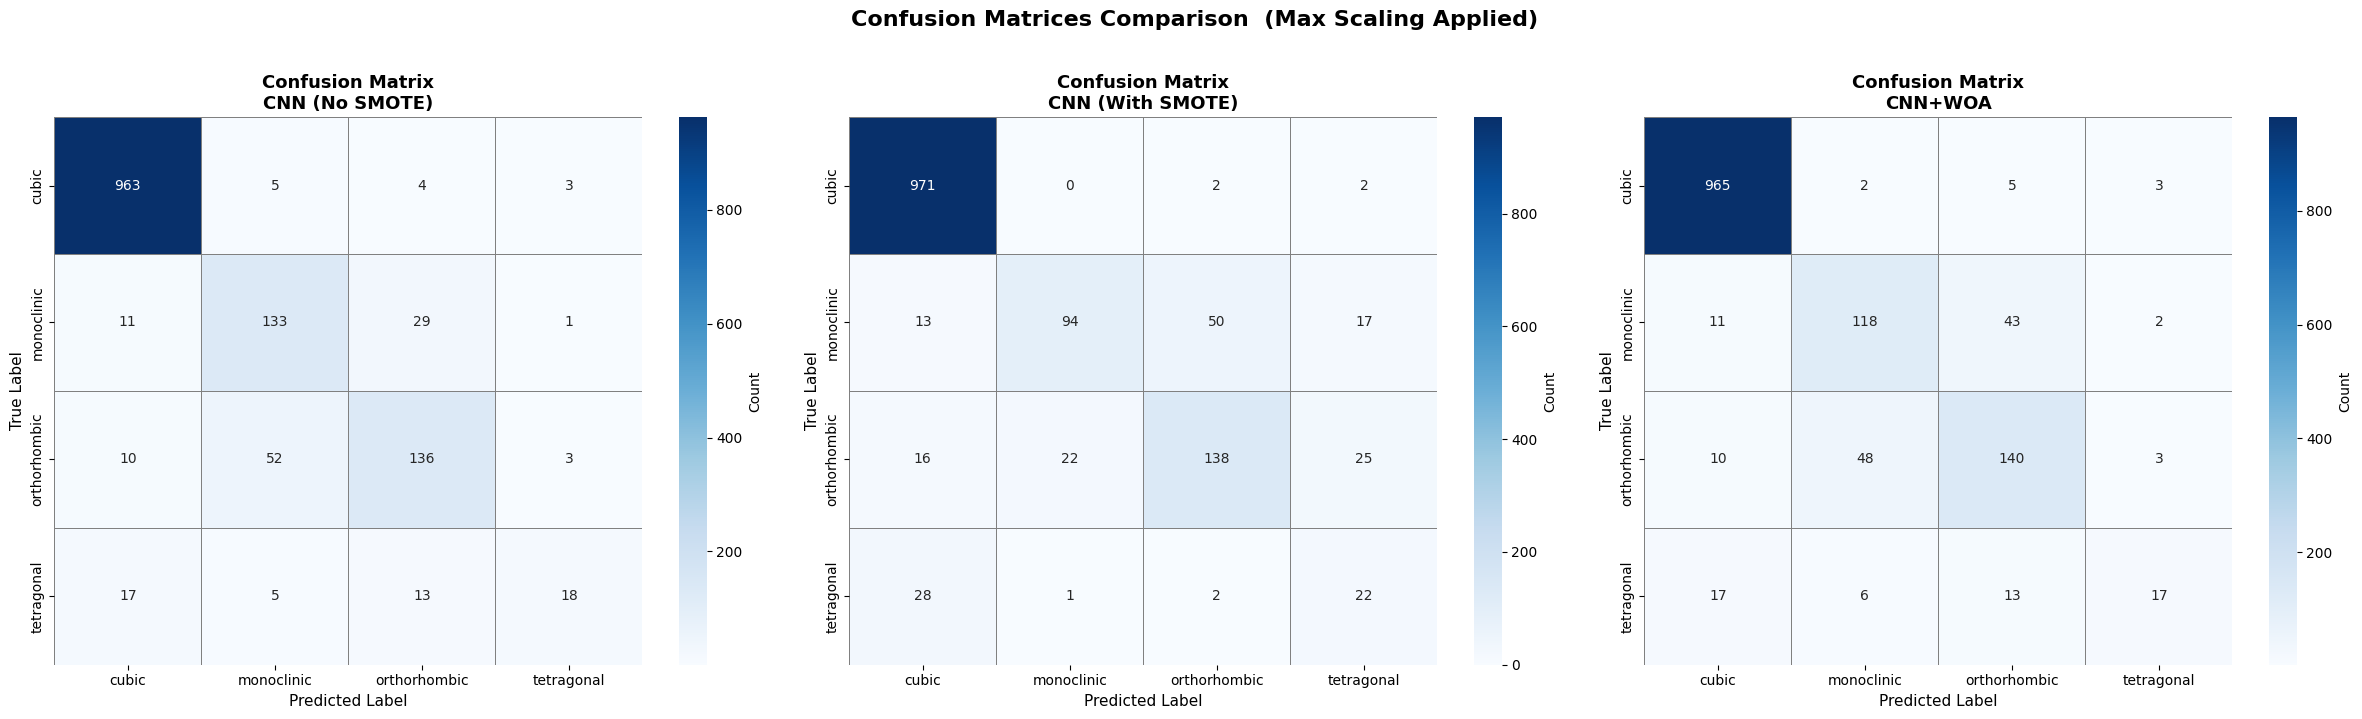

In [ ]:
# ============================================================================
# CONFUSION MATRICES
# ============================================================================

n_models = len(models_results)
fig, axes = plt.subplots(1, n_models, figsize=(8 * n_models, 7))

for idx, (model_name, results) in enumerate(models_results.items()):
    cm = confusion_matrix(y_test, results['predictions'])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'}, linewidths=0.5, linecolor='gray',
                ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix\n{model_name}', fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Predicted Label', fontsize=11)
    axes[idx].set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrices Comparison  (Max Scaling Applied)',
             fontweight='bold', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()